# 🏠 House Price Prediction System
## Using KNN | ML Project

In [324]:
import pandas as pd
import matplotlib.pyplot as plt

In [325]:
df = pd.read_csv("housing_data.csv")
df

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,Downtown,1200,2,1,1,15,0,4500000
1,Downtown,1800,3,2,2,10,1,6800000
2,Downtown,2200,4,3,2,5,1,9200000
3,Downtown,950,1,1,1,20,0,3800000
4,Downtown,3000,5,4,3,3,2,13500000
...,...,...,...,...,...,...,...,...
95,University Area,2800,5,3,2,4,1,8900000
96,University Area,1000,2,1,1,16,0,3100000
97,University Area,1600,3,2,1,11,1,5000000
98,University Area,2200,4,3,2,6,1,6900000


In [326]:
df.shape

(100, 8)

In [327]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,Downtown,1200,2,1,1,15,0,4500000
1,Downtown,1800,3,2,2,10,1,6800000
2,Downtown,2200,4,3,2,5,1,9200000
3,Downtown,950,1,1,1,20,0,3800000
4,Downtown,3000,5,4,3,3,2,13500000


In [328]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   location   100 non-null    object
 1   size_sqft  100 non-null    int64 
 2   bedrooms   100 non-null    int64 
 3   bathrooms  100 non-null    int64 
 4   floors     100 non-null    int64 
 5   age_years  100 non-null    int64 
 6   garage     100 non-null    int64 
 7   price      100 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 6.4+ KB


In [329]:
df.describe()

,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.00000,1.000000e+02
mean,1787.000000,3.10000,2.110000,1.620000,11.580000,0.72000,5.974000e+06
std,739.492728,1.27525,0.962898,0.693112,8.860513,0.69747,2.968407e+06
min,600.000000,1.00000,1.000000,1.000000,1.000000,0.00000,1.600000e+06
25%,1175.000000,2.00000,1.000000,1.000000,5.000000,0.00000,3.775000e+06
50%,1650.000000,3.00000,2.000000,1.500000,9.000000,1.00000,5.250000e+06
75%,2250.000000,4.00000,3.000000,2.000000,15.000000,1.00000,7.550000e+06
max,3500.000000,6.00000,4.000000,3.000000,45.000000,2.00000,1.520000e+07


In [330]:
df.isna().sum()

location     0
size_sqft    0
bedrooms     0
bathrooms    0
floors       0
age_years    0
garage       0
price        0
dtype: int64

In [331]:
df.duplicated().sum()

0

In [332]:
df.location.unique()

array(['Downtown', 'Suburbs', 'Midtown', 'Old City', 'IT Hub',
       'Green Valley', 'University Area'], dtype=object)

### EDA

In [333]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,Downtown,1200,2,1,1,15,0,4500000
1,Downtown,1800,3,2,2,10,1,6800000
2,Downtown,2200,4,3,2,5,1,9200000
3,Downtown,950,1,1,1,20,0,3800000
4,Downtown,3000,5,4,3,3,2,13500000


#### 1. Price Distribution

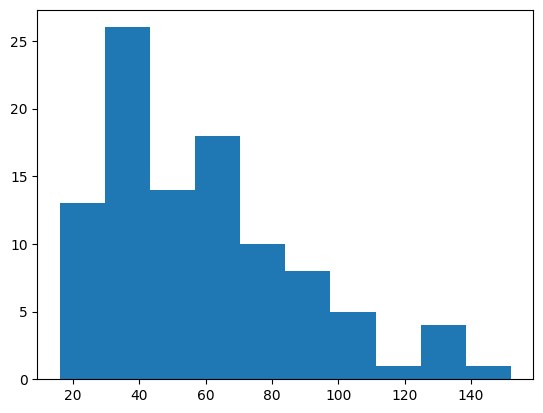

In [334]:
plt.hist(df.price / 1e5);

5250000.0


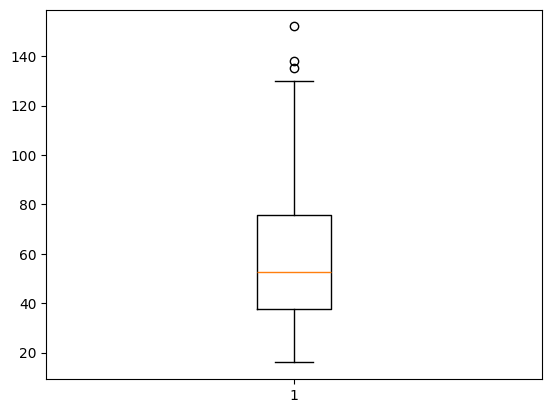

In [335]:
print(df.price.median())
plt.boxplot(df.price / 1e5);

#### 2. Average Price by Location

In [336]:
df.location.unique()

array(['Downtown', 'Suburbs', 'Midtown', 'Old City', 'IT Hub',
       'Green Valley', 'University Area'], dtype=object)

In [337]:
avg_price = df.groupby('location')['price'].mean().sort_values(ascending=False)/1e5

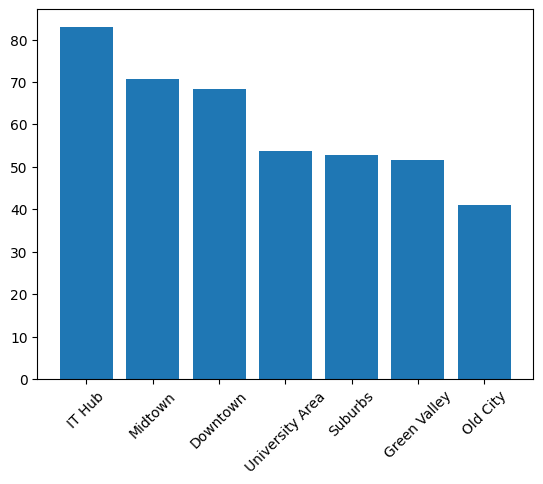

In [338]:
plt.bar(avg_price.index, avg_price.values)
plt.xticks(rotation=45);

In [339]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,Downtown,1200,2,1,1,15,0,4500000
1,Downtown,1800,3,2,2,10,1,6800000
2,Downtown,2200,4,3,2,5,1,9200000
3,Downtown,950,1,1,1,20,0,3800000
4,Downtown,3000,5,4,3,3,2,13500000


#### 3. Size Vs Price 

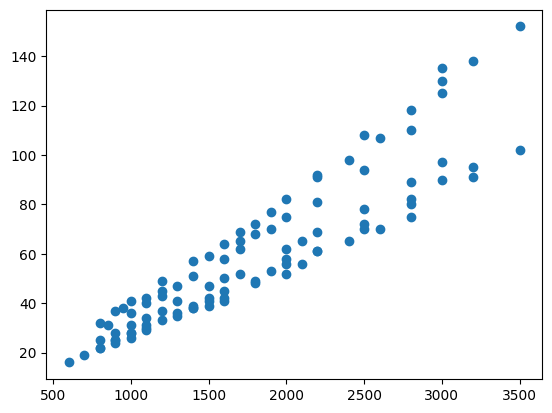

In [340]:
plt.scatter(df.size_sqft, df.price/1e5)

#### Feature Engineering

In [341]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,Downtown,1200,2,1,1,15,0,4500000
1,Downtown,1800,3,2,2,10,1,6800000
2,Downtown,2200,4,3,2,5,1,9200000
3,Downtown,950,1,1,1,20,0,3800000
4,Downtown,3000,5,4,3,3,2,13500000


In [342]:
df.location.unique()

array(['Downtown', 'Suburbs', 'Midtown', 'Old City', 'IT Hub',
       'Green Valley', 'University Area'], dtype=object)

In [343]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.location = le.fit_transform(df.location)

In [344]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,0,1200,2,1,1,15,0,4500000
1,0,1800,3,2,2,10,1,6800000
2,0,2200,4,3,2,5,1,9200000
3,0,950,1,1,1,20,0,3800000
4,0,3000,5,4,3,3,2,13500000


In [345]:
for (cat, en) in zip(le.classes_, le.transform(le.classes_)):
    print(cat, en)

Downtown 0
Green Valley 1
IT Hub 2
Midtown 3
Old City 4
Suburbs 5
University Area 6


In [346]:
import joblib
joblib.dump(le, "location_le.joblib")

['location_le.joblib']

In [347]:
df.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage,price
0,0,1200,2,1,1,15,0,4500000
1,0,1800,3,2,2,10,1,6800000
2,0,2200,4,3,2,5,1,9200000
3,0,950,1,1,1,20,0,3800000
4,0,3000,5,4,3,3,2,13500000


In [348]:
x = df.drop('price', axis=1)
y = df.price

In [349]:
x.head()

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage
0,0,1200,2,1,1,15,0
1,0,1800,3,2,2,10,1
2,0,2200,4,3,2,5,1
3,0,950,1,1,1,20,0
4,0,3000,5,4,3,3,2


In [350]:
y.head()

0     4500000
1     6800000
2     9200000
3     3800000
4    13500000
Name: price, dtype: int64

In [351]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20 )

In [352]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)
model.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [353]:
y_pred = model.predict(x_test)
y_pred

array([ 2560000., 11400000.,  7880000.,  3900000.,  7040000.,  2980000.,
        3780000.,  3920000.,  7820000.,  9520000.,  8780000.,  6660000.,
       12060000.,  8560000.,  4620000.,  3380000.,  7820000.,  3380000.,
        6600000.,  3860000.])

In [354]:
from sklearn.metrics import mean_squared_error, r2_score

print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

1639200000000.0
0.7439790085277855


In [355]:
x.head(1)

,location,size_sqft,bedrooms,bathrooms,floors,age_years,garage
0,0,1200,2,1,1,15,0


In [356]:
new_house = [[0, 1800, 2, 1, 1, 40, 0]]
model.predict(new_house)

c:\Users\visha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([5980000.])